# Motivation Score Regression Model

This notebook trains a regression model to predict `motivation_score`.

Unlike dropout proxy classification, this is a continuous behavioral construct.

Motivation is calculated as:

`motivation_score = (M1 + M2 + M3 + M4) / 4`

This makes it a stable and well-distributed regression target.

The goal is to evaluate predictive power using contextual and behavioral features.

This model is suitable for dashboard insights and chatbot interpretation.

## Feature Selection Rationale

The target is `motivation_score`.

To avoid leakage, the following variables are excluded:
- `M1_estimulante`, `M2_aumenta_interes`, `M3_aporta_valor`, `M4_mayor_esfuerzo`
- `delta_motivation_score`
- `motivation_improved`

Other engineered behavioral aggregates excluded:
- `dependency_risk`
- `dependency_level`
- `dependency_risk_high`
- `self_efficacy_score`
- `composite_roi_score`
- `AT_mean`, `D_mean`, `E_mean`
- `C3_inv`, `C4_inv`

Only contextual, demographic, and AI usage variables are used.

In [1]:
# Import only allowed libraries and required sklearn components.
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold, cross_validate, cross_val_predict


def _find_project_root(start_path: str) -> str:
    """Find project root by walking up until .env and backend directory are found."""
    current = os.path.abspath(start_path)
    while True:
        env_candidate = os.path.join(current, '.env')
        backend_candidate = os.path.join(current, 'backend')
        if os.path.isfile(env_candidate) and os.path.isdir(backend_candidate):
            return current
        parent = os.path.dirname(current)
        if parent == current:
            break
        current = parent
    raise ValueError('Could not locate project root containing .env and backend directory.')


def _read_env_value(env_file: str, key: str) -> str:
    """Read one key from .env file without external dependencies."""
    if not os.path.isfile(env_file):
        return ''
    with open(env_file, 'r', encoding='utf-8') as f:
        for line in f:
            raw = line.strip()
            if not raw or raw.startswith('#') or '=' not in raw:
                continue
            k, v = raw.split('=', 1)
            if k.strip() == key:
                return v.strip().strip('\"').strip("'")
    return ''


# Resolve project root and .env path.
project_root = _find_project_root(os.getcwd())
env_path = os.path.join(project_root, '.env')

# Resolve engineered dataset directory from environment with safe fallback.
engineered_data_dir = os.getenv('ENGINEERED_DATA_DIR') or _read_env_value(env_path, 'ENGINEERED_DATA_DIR') or 'backend/data/processed'
if not os.path.isabs(engineered_data_dir):
    engineered_data_dir = os.path.join(project_root, engineered_data_dir)

# Load engineered dataset generated previously.
processed_path = os.path.join(engineered_data_dir, 'survey_engineered.csv')
if not os.path.exists(processed_path):
    raise FileNotFoundError(f'Engineered dataset not found at: {processed_path}')

df = pd.read_csv(processed_path)
print(f'Engineered dataset loaded from: {processed_path}')
print(f'Dataset shape: {df.shape}')

# Validate target column exists.
if 'motivation_score' not in df.columns:
    raise ValueError("Required target column 'motivation_score' not found in dataset.")

Engineered dataset loaded from: /workspaces/EvaluAI/backend/data/processed/survey_engineered.csv
Dataset shape: (100, 55)


In [2]:
# Define leakage-free structural features (same family as dropout clean model).
demographic_features = [
    'edad',
    'antiguedad_empresa',
    'rol_tecnico'
]

ai_usage_features = [
    'frecuencia_uso_ia',
    'usa_chatgpt',
    'usa_gemini',
    'usa_copilot',
    'usa_lms_ia',
    'usa_otra_ia',
    'prefiere_humano_vs_ia',
    'nivel_integracion_ia'
]

categorical_features = [
    'genero',
    'departamento',
    'sector',
    'nivel_educativo',
    'herramienta_principal'
]

required_columns = demographic_features + ai_usage_features + categorical_features + ['motivation_score']
missing_columns = [c for c in required_columns if c not in df.columns]
if missing_columns:
    raise ValueError(f'Missing required columns: {missing_columns}')

# Create raw feature frame from whitelisted leakage-free variables only.
X_raw = df[demographic_features + ai_usage_features + categorical_features].copy()

# Convert numeric whitelist to numeric values and handle missing values robustly.
numeric_whitelist = demographic_features + ai_usage_features
for col in numeric_whitelist:
    X_raw[col] = pd.to_numeric(X_raw[col], errors='coerce')

X_raw[numeric_whitelist] = X_raw[numeric_whitelist].fillna(X_raw[numeric_whitelist].median())

# One-hot encode categorical variables as requested.
X_raw[categorical_features] = X_raw[categorical_features].fillna('Unknown').astype(str)
X = pd.get_dummies(X_raw, columns=categorical_features, drop_first=True)

# Define continuous regression target.
y = pd.to_numeric(df['motivation_score'], errors='coerce')
if y.isnull().any():
    y = y.fillna(y.median())

print(f'Feature count: {X.shape[1]}')
print(f'X shape: {X.shape}')
print(f'y shape: {y.shape}')

Feature count: 28
X shape: (100, 28)
y shape: (100,)


In [3]:
# Initialize the requested RandomForestRegressor configuration.
rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=8,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

# Define reproducible K-Fold strategy.
cv = KFold(n_splits=5, shuffle=True, random_state=42)

# Define requested regression metrics.
scoring = {
    'r2': 'r2',
    'neg_mean_absolute_error': 'neg_mean_absolute_error',
    'neg_root_mean_squared_error': 'neg_root_mean_squared_error'
}

# Run cross-validation with both train and test scores.
cv_results = cross_validate(
    rf_model,
    X,
    y,
    cv=cv,
    scoring=scoring,
    return_train_score=True,
    n_jobs=-1
)

print('Cross-validation completed successfully.')

Cross-validation completed successfully.


In [4]:
# Build summary table and convert negative sklearn errors to positive MAE/RMSE.
test_r2 = cv_results['test_r2']
train_r2 = cv_results['train_r2']

test_mae = -cv_results['test_neg_mean_absolute_error']
train_mae = -cv_results['train_neg_mean_absolute_error']

test_rmse = -cv_results['test_neg_root_mean_squared_error']
train_rmse = -cv_results['train_neg_root_mean_squared_error']

cv_summary = pd.DataFrame([
    {
        'metric': 'R2',
        'test_mean': float(np.mean(test_r2)),
        'test_std': float(np.std(test_r2)),
        'train_mean': float(np.mean(train_r2)),
        'train_std': float(np.std(train_r2)),
        'train_test_gap': float(np.mean(train_r2) - np.mean(test_r2))
    },
    {
        'metric': 'MAE',
        'test_mean': float(np.mean(test_mae)),
        'test_std': float(np.std(test_mae)),
        'train_mean': float(np.mean(train_mae)),
        'train_std': float(np.std(train_mae)),
        'train_test_gap': float(np.mean(train_mae) - np.mean(test_mae))
    },
    {
        'metric': 'RMSE',
        'test_mean': float(np.mean(test_rmse)),
        'test_std': float(np.std(test_rmse)),
        'train_mean': float(np.mean(train_rmse)),
        'train_std': float(np.std(train_rmse)),
        'train_test_gap': float(np.mean(train_rmse) - np.mean(test_rmse))
    }
])

display_df = cv_summary.copy()
for col in ['test_mean', 'test_std', 'train_mean', 'train_std', 'train_test_gap']:
    display_df[col] = display_df[col].round(4)

print('Cross-validation summary:')
print(display_df.to_string(index=False))

Cross-validation summary:
metric  test_mean  test_std  train_mean  train_std  train_test_gap
    R2    -0.3304    0.2634      0.7350     0.0113          1.0653
   MAE     0.8643    0.0932      0.3761     0.0073         -0.4882
  RMSE     1.0754    0.1326      0.5007     0.0112         -0.5747


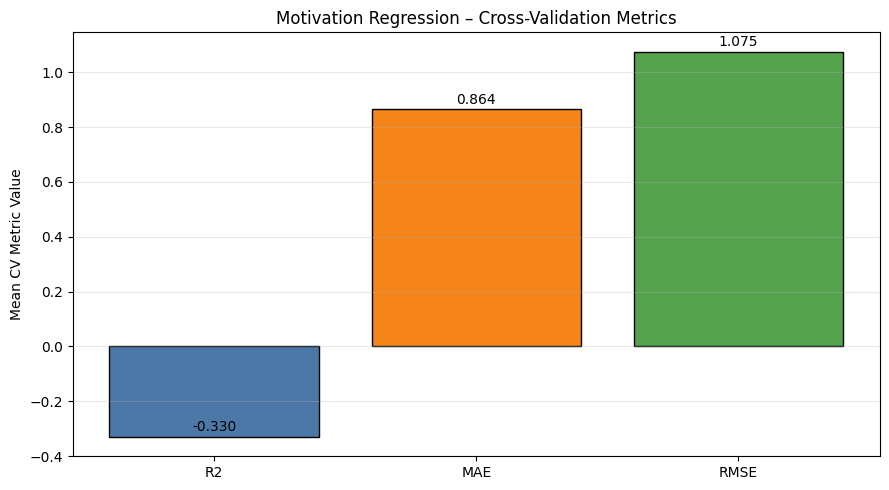

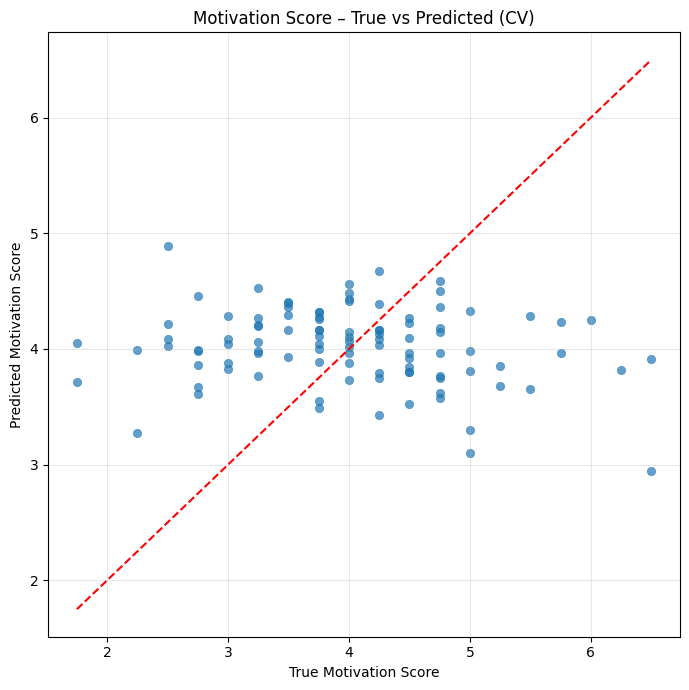

In [5]:
# Plot 1: Bar chart for mean R2, MAE, RMSE from cross-validation.
plt.figure(figsize=(9, 5))
bars = plt.bar(cv_summary['metric'], cv_summary['test_mean'], color=['#4C78A8', '#F58518', '#54A24B'], edgecolor='black')

for bar, value in zip(bars, cv_summary['test_mean']):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01, f'{value:.3f}', ha='center', va='bottom')

plt.title('Motivation Regression – Cross-Validation Metrics')
plt.ylabel('Mean CV Metric Value')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Plot 2: True vs Predicted using cross-validated predictions.
y_pred_cv = cross_val_predict(rf_model, X, y, cv=cv, n_jobs=-1)

plt.figure(figsize=(7, 7))
sns.scatterplot(x=y, y=y_pred_cv, alpha=0.7, edgecolor=None)

min_val = min(float(np.min(y)), float(np.min(y_pred_cv)))
max_val = max(float(np.max(y)), float(np.max(y_pred_cv)))
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=1.5)

plt.xlabel('True Motivation Score')
plt.ylabel('Predicted Motivation Score')
plt.title('Motivation Score – True vs Predicted (CV)')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [6]:
# Train final model on full dataset for deployment artifacts.
final_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=8,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

final_model.fit(X, y)

feature_importance_df = pd.DataFrame({
    'feature': X.columns,
    'importance': final_model.feature_importances_
}).sort_values('importance', ascending=False).reset_index(drop=True)

print('Top 10 feature importances:')
print(feature_importance_df.head(10).to_string(index=False))

Top 10 feature importances:
                      feature  importance
                         edad    0.177271
           antiguedad_empresa    0.109994
         nivel_integracion_ia    0.101421
            frecuencia_uso_ia    0.069437
        prefiere_humano_vs_ia    0.055434
herramienta_principal_Copilot    0.048321
   herramienta_principal_Otra    0.043207
                   usa_gemini    0.040800
            sector_Tecnología    0.036320
                   usa_lms_ia    0.026525


In [7]:
# Resolve model output directory from environment and .env with fallback.
model_dir = os.getenv('MODEL_PATH') or _read_env_value(env_path, 'MODEL_PATH') or 'backend/ml/models'
if not os.path.isabs(model_dir):
    model_dir = os.path.join(project_root, model_dir)

os.makedirs(model_dir, exist_ok=True)

# Save trained model artifact.
model_path = os.path.join(model_dir, 'motivation_score_model.pkl')
joblib.dump(final_model, model_path)

# Build metadata payload with requested fields.
metadata = {
    'model_type': 'RandomForestRegressor',
    'parameters': {
        'n_estimators': 300,
        'max_depth': 8,
        'min_samples_split': 5,
        'min_samples_leaf': 2,
        'random_state': 42
    },
    'n_features': int(X.shape[1]),
    'feature_names': X.columns.tolist(),
    'target': 'motivation_score',
    'cross_validation_metrics': {
        'r2': float(np.mean(test_r2)),
        'mae': float(np.mean(test_mae)),
        'rmse': float(np.mean(test_rmse))
    },
    'note': 'Leakage-free regression model',
    'timestamp': pd.Timestamp.utcnow().isoformat()
}

metadata_path = os.path.join(model_dir, 'motivation_score_model_metadata.json')
with open(metadata_path, 'w', encoding='utf-8') as f:
    json.dump(metadata, f, indent=2)

print(f'Model saved to: {model_path}')
print(f'Metadata saved to: {metadata_path}')

Model saved to: /workspaces/EvaluAI/backend/ml/models/motivation_score_model.pkl
Metadata saved to: /workspaces/EvaluAI/backend/ml/models/motivation_score_model_metadata.json


## Final Interpretation & Business Meaning

### Interpretation of Metrics

- **R²**: explains how much variance in motivation is captured.
  - `> 0.6`: strong
  - `0.3 to 0.6`: moderate
  - `< 0.3`: weak

- **MAE**: average absolute prediction error.
  - Since motivation scale is 1-7, MAE < 0.7 is generally acceptable.

- **RMSE**: penalizes larger errors and should be interpreted relative to target spread (std around 0.98).

### Business Interpretation

If R² is moderate or strong, motivation is partially predictable from:
- AI usage patterns
- Integration level
- Demographic and organizational context

Feature importance provides directional insight, not causation.

### Model Consumers

- Backend `/predict` endpoint
- Dashboard motivational risk indicator
- Chatbot coaching suggestions

### Limitations

- Sample size is limited to 100 records
- Dataset is cross-sectional
- Retraining is recommended when new survey waves are collected

This model represents predictive capacity from contextual and behavioral signals,
not from direct psychometric inputs.